In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import kwant
import matplotlib.pyplot as plt
# from koala import pointsets

from tai_localizer.lauralizer.amorphous_model_3D import amorph_hopping, amorph_3DTI
from tai_localizer.lauralizer.functions import bonds_func, zero_params, sigma_y
from tai_localizer.lauralizer.localizer import spectral_localizer_AII3D, sign_det, ctx

In [ ]:


def grid_3D(nx: int , ny: int, nz: int) -> np.ndarray:
    """Generates a uniformly spaced grid of points in 3D

    Args:
        nx (int): Number of points in x direction
        ny (int): Number of points in y direction
        nz (int): Number of points in z direction

    Returns:
        np.ndarray: List of all the positions.
    """

    pos_x = np.linspace(0,1,nx, endpoint=False)
    pos_y = np.linspace(0,1,ny, endpoint=False)
    pos_z = np.linspace(0,1,nz, endpoint=False)
    pos_x += 0.5*pos_x[0]
    pos_y += 0.5*pos_y[0]
    pos_z += 0.5*pos_z[0]
    g_out = np.reshape(np.meshgrid(pos_x, pos_y, pos_z), [3,-1]).T
    return g_out

c:\Users\Laura\miniconda3\envs\dec2025\Lib\site-packages\kwant\_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"
c:\Users\Laura\miniconda3\envs\dec2025\Lib\site-packages\kwant\_plotter.py:416: MatplotlibDeprecationWarning: The proj_transform_clip function was deprecated in Matplotlib 3.10 and will be removed in 3.12.
  vs = np.array(proj(xs, ys, zs, self.axes.M)[:3])
c:\Users\Laura\miniconda3\envs\dec2025\Lib\site-packages\kwant\_plotter.py:472: MatplotlibDeprecationWarning: The proj_transform_clip function was deprecated in Matplotlib 3.10 and will be removed in 3.12.
  cz = proj(*(list(np.dot(corners, bbox)) + [self.axes.M]))[2]


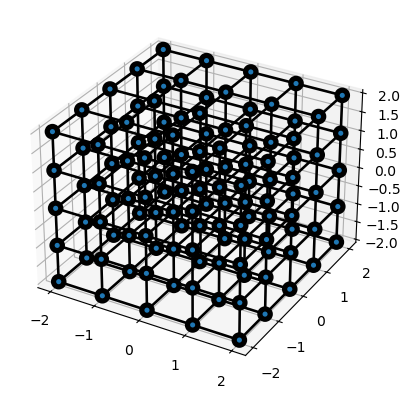

(<Figure size 640x480 with 1 Axes>,)

In [11]:
kwant.plot(syst   , site_size=0.1, hop_lw=0.05),


In [ ]:
system_size = 5
bond_distance = 1.01 / system_size
L = 5
a = 1
num_points = int(np.floor(L / a))
offset = (num_points - 1) * a / 2  # shift to center the cube at origin
coords = np.arange(num_points) * a - offset
X, Y, Z = np.meshgrid(coords, coords, coords, indexing='ij')
sites = np.vstack((X.ravel(), Y.ravel(), Z.ravel())).T
# sites = grid_3D(system_size, system_size, system_size)
bonds = bonds_func(sites, 1.01)
syst = amorph_3DTI(sites, bonds)
sys_sites = syst.finalized().sites
positions = [site.pos for site in sys_sites]
fsys = syst.finalized()

In [13]:
# params = dict(
#     pbc=False,
#     R=1.01,
#     MJ=2.3,
#     lambdaJ=1,
#     norbs=4,
#     name='a',
#     dis_onsite=0,
#     )

zeroparams = zero_params(syst.finalized())
rng = np.random.default_rng()
new_params = {
    'MJ': 2.3,
    'lambdaJ': 1.0,
    'bond_lengthscale': 1.01,
    'bond_power': 1.0,
    'dis_onsite': 0.0,
    'rng_W': rng,
}

ham = syst.finalized().hamiltonian_submatrix(params=new_params, sparse=True)



In [14]:
L = spectral_localizer_AII3D(
    np.array(positions),
    ham,
    0,
    0.2
)

0.0 0.0 0.0


In [15]:
sign_det(L)

-1.0

In [221]:
H = ham.todense()
TR = np.kron(np.kron(np.eye(len(sys_sites)), np.eye(2)), sigma_y)
commutator = H @ TR - TR @ np.conj(H)
np.linalg.norm(commutator)

np.float64(0.0)

# dos

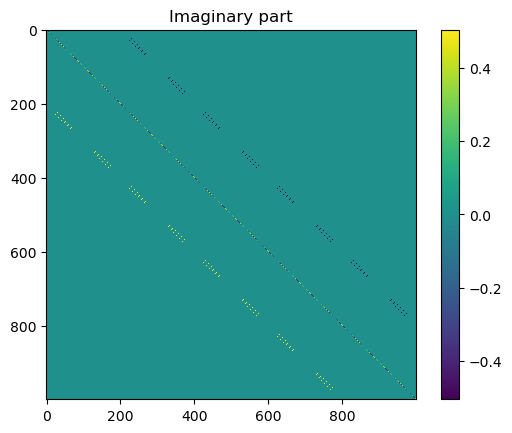

In [301]:
#plot imag and real matrix with colormesh
import matplotlib.pyplot as plt
plt.figure()
#
plt.title("Imaginary part")
plt.imshow(L.imag.todense(), cmap='viridis', interpolation='none')
plt.colorbar()

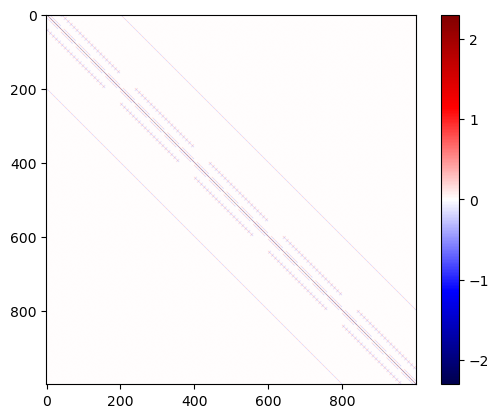

In [291]:
# plot matrix in imshow
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(L.todense().real, cmap='seismic', vmin=np.real(L.min()), vmax=np.real(L.max()))
# plt.imshow(L.todense().imag, cmap='seismic', vmin=np.imag(L.min()), vmax=np.imag(L.max()))

plt.colorbar()

(-1.0, 1.0)

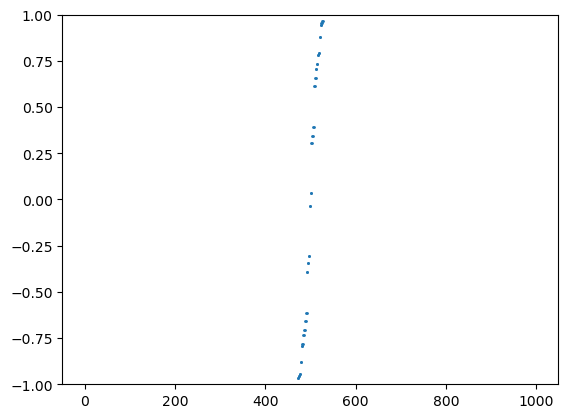

In [305]:
#plot evals of ham
evals = np.linalg.eigvalsh((L.todense()))
plt.figure()
plt.scatter(range(len(evals)), evals, s=1)
plt.ylim(-1,1)

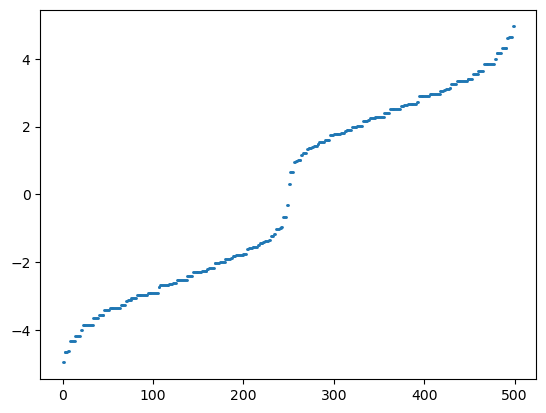

In [197]:
kwant_op = kwant.operator.Density(fsys, sum=False)
local_dos = kwant.kpm.SpectralDensity(fsys, params=new_params, operator=kwant_op, energy_resolution=0.05)

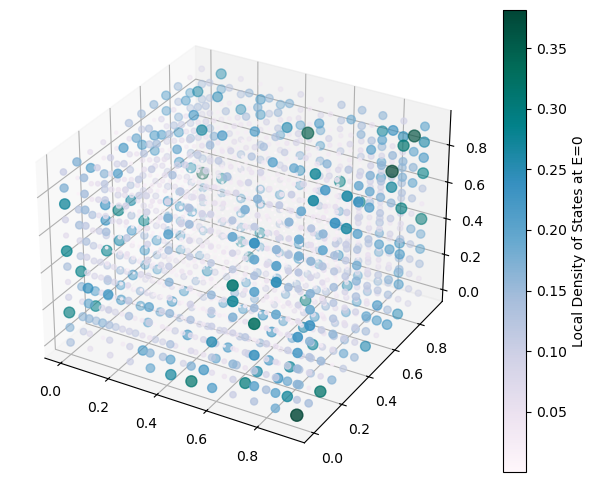

In [198]:


# Compute the local density of states at zero energy
ldos_real_space = np.abs(local_dos(0.4)).real
sites = np.array([site.pos for site in fsys.sites])
plt.figure(figsize=(8,6))
# 3d plot
ax = plt.axes(projection='3d')
b =ax.scatter(sites[:, 0], sites[:, 1], sites[:, 2], c=ldos_real_space, cmap='PuBuGn', s=200*ldos_real_space)
plt.colorbar(b, ax=ax, label='Local Density of States at E=0')
